# Alzheimer's MRI Classification -- Custom CNN (Baseline)
**Dataset:** ADNI axial MRI slices (CN / AD / EMCI / LMCI), from `src/data_prep.py`
**Model:** small from-scratch CNN, built in `src/models.py`

This is the fastest of the three models (Phase C) -- it validates the whole pipeline (data loading, subject-wise split, training loop, evaluation) before we invest time in the MobileNetV2/EfficientNet-B0 transfer learning in Phase D.

## 1. Imports

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import CLASSES, build_dataloaders, compute_class_weights
from models import SimpleCNN
from train import train_model
from evaluate import get_predictions, slice_level_report, subject_level_report

%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, '-', torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU only')

Device: cuda - NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 2. Configuration

In [2]:
MANIFEST_PATH = '../data/manifest.csv'
CHECKPOINT_PATH = '../models/checkpoints/custom_cnn.pt'
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 5  # early stopping: stop if val_loss doesn't improve for this many epochs

torch.manual_seed(42)
np.random.seed(42)

## 3. Load Dataset

Reads `data/manifest.csv` (built in Phase B), which already has each image's `split` (train/val/test)
and `class` label. The subject-wise split happened back in `data_prep.py`, before any images existed --
by this point it's just a table of filepaths, so there's no way for leakage to sneak in here.

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)
print('Total images:', len(manifest))
print(manifest.groupby(['split', 'class']).size().unstack())

# The single most important sanity check given what went wrong in the earlier models:
# no subject should ever appear in more than one split.
subjects_per_split = manifest.groupby('subject_id')['split'].nunique()
assert (subjects_per_split == 1).all(), 'LEAKAGE: a subject appears in more than one split!'
print('\nOK: every subject appears in exactly one split (no leakage).')

Total images: 14048
class    AD    CN  EMCI  LMCI
split                        
test    352   480   672   608
train  1728  2176  3136  2784
val     384   448   672   608

OK: every subject appears in exactly one split (no leakage).


## 4. Class Distribution Plot

C:\Users\Nikunj\AppData\Local\Temp\ipykernel_7448\3049626451.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=train_counts.index, y=train_counts.values, palette='Blues_d')


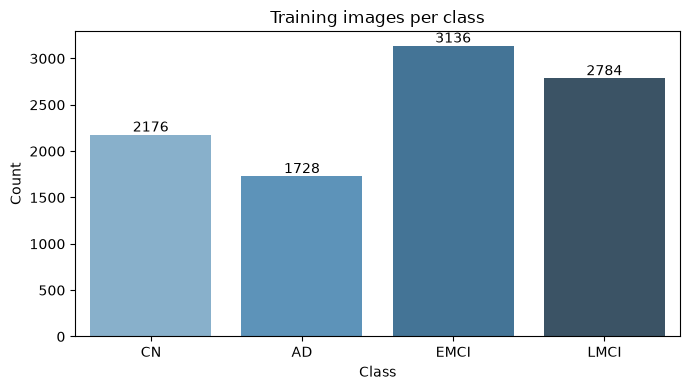

In [4]:
train_counts = manifest[manifest['split'] == 'train']['class'].value_counts().reindex(CLASSES)

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=train_counts.index, y=train_counts.values, palette='Blues_d')
ax.set_title('Training images per class')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 5. DataLoaders + Class Weights

Equivalent of the old notebook's `ImageDataGenerator.flow_from_dataframe()` calls. `compute_class_weights`
gives AD (the smallest class) more weight in the loss so the model doesn't just learn to favor the bigger classes.

In [5]:
train_loader, val_loader, test_loader = build_dataloaders(manifest, batch_size=BATCH_SIZE)
class_weights = compute_class_weights(manifest)

print('Batches -- train:', len(train_loader), ' val:', len(val_loader), ' test:', len(test_loader))
print('Class weights:', dict(zip(CLASSES, class_weights.tolist())))

Batches -- train: 307  val: 66  test: 66
Class weights: {'CN': 1.0710233449935913, 'AD': 1.3486961126327515, 'EMCI': 0.7431590557098389, 'LMCI': 0.8371217250823975}


## 6. Preview Sample Images

Same sanity habit as the old notebook -- look at what the model will actually see before training on it.

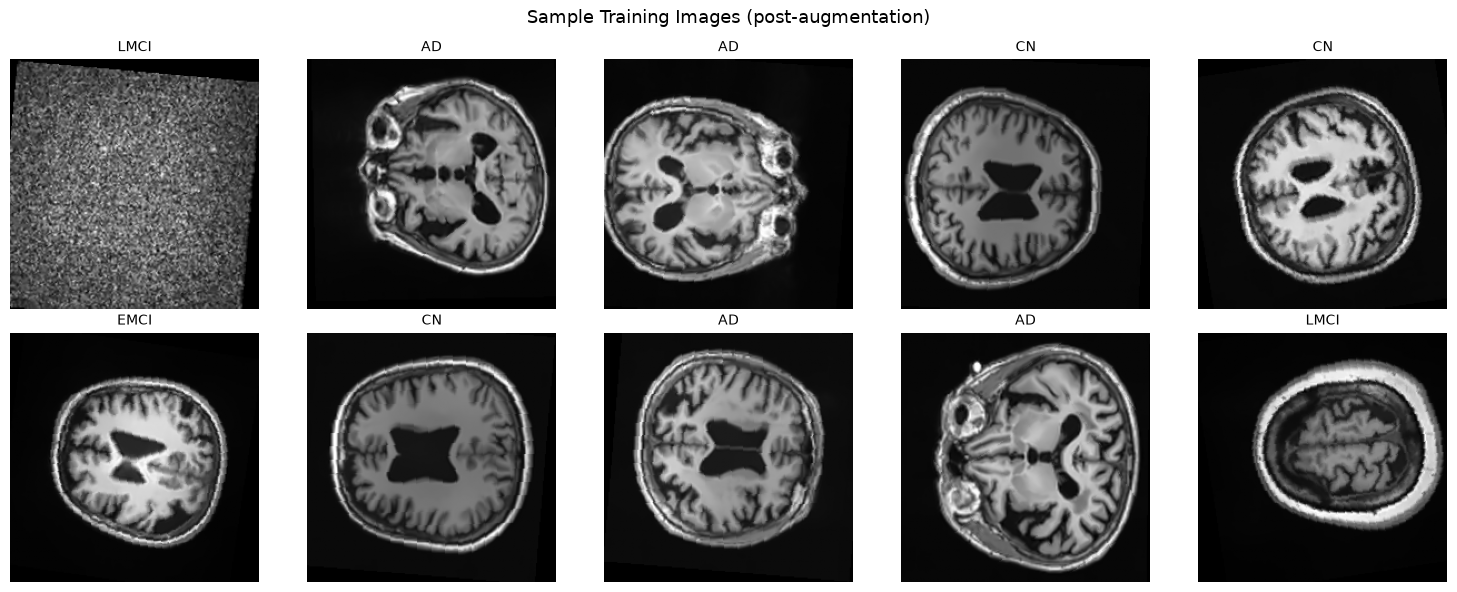

In [6]:
batch_images, batch_labels, _ = next(iter(train_loader))
display_images = batch_images * 0.5 + 0.5  # undo the Normalize(mean=0.5, std=0.5) for display

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(display_images[i, 0], cmap='gray')
    ax.set_title(CLASSES[batch_labels[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Training Images (post-augmentation)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Build Model

In [7]:
model = SimpleCNN(num_classes=len(CLASSES))
n_params = sum(p.numel() for p in model.parameters())
print(f'SimpleCNN: {n_params:,} parameters')
model

SimpleCNN: 1,207,012 parameters


SimpleCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (3): MaxPool2d(kernel_size=2, 

## 8. Train the Model

`train_model` (in `src/train.py`) handles early stopping and LR reduction internally -- same behavior as the
old notebook's `EarlyStopping(patience=4, restore_best_weights=True)` + `ReduceLROnPlateau` callbacks, just
written as plain Python since PyTorch doesn't have callback objects built into training.

In [8]:
history = train_model(
    model, train_loader, val_loader, class_weights, device,
    epochs=EPOCHS, lr=LEARNING_RATE, patience=PATIENCE, checkpoint_path=CHECKPOINT_PATH,
)

Epoch  1/30 - train_loss 0.9242 train_acc 0.4792 - val_loss 1.5417 val_acc 0.3523
Epoch  2/30 - train_loss 0.8193 train_acc 0.5269 - val_loss 1.1971 val_acc 0.4238
Epoch  3/30 - train_loss 0.7840 train_acc 0.5505 - val_loss 0.9847 val_acc 0.4413
Epoch  4/30 - train_loss 0.7310 train_acc 0.5870 - val_loss 0.8151 val_acc 0.4801
Epoch  5/30 - train_loss 0.7137 train_acc 0.6050 - val_loss 1.3410 val_acc 0.4484
Epoch  6/30 - train_loss 0.6740 train_acc 0.6221 - val_loss 1.5629 val_acc 0.4920
Epoch  7/30 - train_loss 0.6525 train_acc 0.6281 - val_loss 0.7672 val_acc 0.5384
Epoch  8/30 - train_loss 0.6418 train_acc 0.6350 - val_loss 0.7726 val_acc 0.5715
Epoch  9/30 - train_loss 0.6325 train_acc 0.6456 - val_loss 1.1136 val_acc 0.4517
Epoch 10/30 - train_loss 0.6185 train_acc 0.6618 - val_loss 0.7211 val_acc 0.5606
Epoch 11/30 - train_loss 0.6056 train_acc 0.6587 - val_loss 2.3786 val_acc 0.4811
Epoch 12/30 - train_loss 0.5853 train_acc 0.6748 - val_loss 1.2098 val_acc 0.4626
Epoch 13/30 - tr

## 9. Training Curves

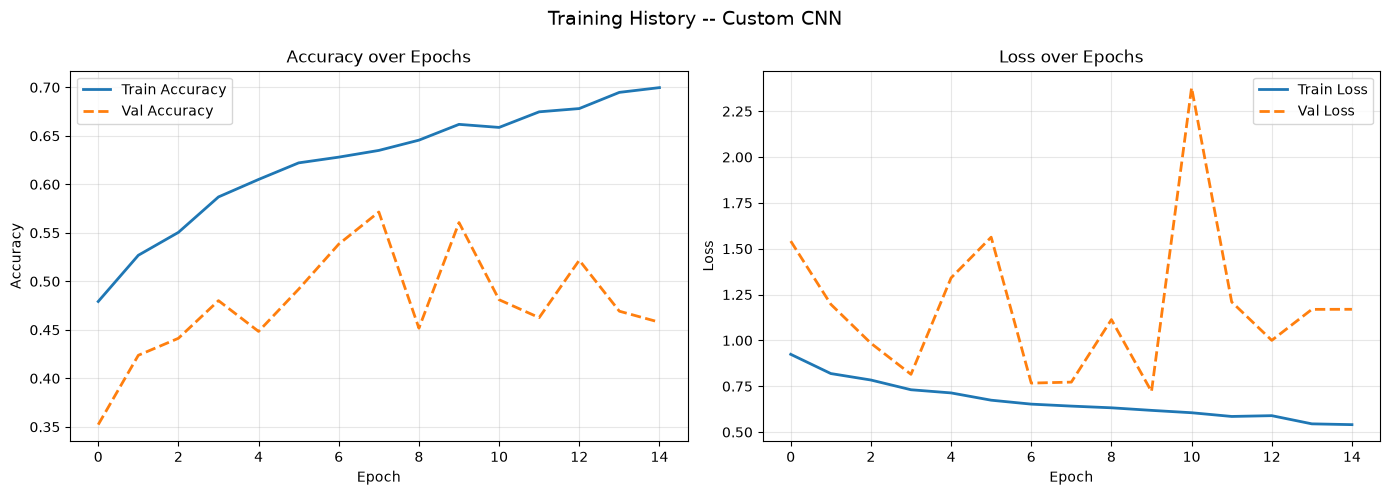

In [9]:
epochs_range = range(len(history['train_loss']))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history['train_acc'], label='Train Accuracy', linewidth=2)
ax1.plot(epochs_range, history['val_acc'], label='Val Accuracy', linewidth=2, linestyle='--')
ax1.set_title('Accuracy over Epochs'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_loss'], label='Train Loss', linewidth=2)
ax2.plot(epochs_range, history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
ax2.set_title('Loss over Epochs'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History -- Custom CNN', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Evaluate on Test Set

Two levels of accuracy, as explained at the top of `src/evaluate.py`:
- **slice-level** -- every one of the 32 images per test subject counted separately
- **subject-level** -- majority vote across a subject's 32 predictions -> one prediction per person. This is the number that actually matters.

In [10]:
test_preds = get_predictions(model, test_loader, device)

print('=' * 60)
print('SLICE-LEVEL classification report')
print('=' * 60)
slice_cm = slice_level_report(test_preds)

print()
print('=' * 60)
print('SUBJECT-LEVEL classification report (majority vote)')
print('=' * 60)
subject_cm, subject_preds = subject_level_report(test_preds)

SLICE-LEVEL classification report
              precision    recall  f1-score   support

          CN       0.65      0.67      0.66       480
          AD       0.50      0.38      0.43       352
        EMCI       0.53      0.73      0.61       672
        LMCI       0.46      0.32      0.38       608

    accuracy                           0.54      2112
   macro avg       0.53      0.53      0.52      2112
weighted avg       0.53      0.54      0.53      2112


SUBJECT-LEVEL classification report (majority vote)
              precision    recall  f1-score   support

          CN       0.61      0.73      0.67        15
          AD       0.50      0.27      0.35        11
        EMCI       0.55      0.76      0.64        21
        LMCI       0.54      0.37      0.44        19

    accuracy                           0.56        66
   macro avg       0.55      0.53      0.52        66
weighted avg       0.55      0.56      0.54        66



## 11. Confusion Matrices

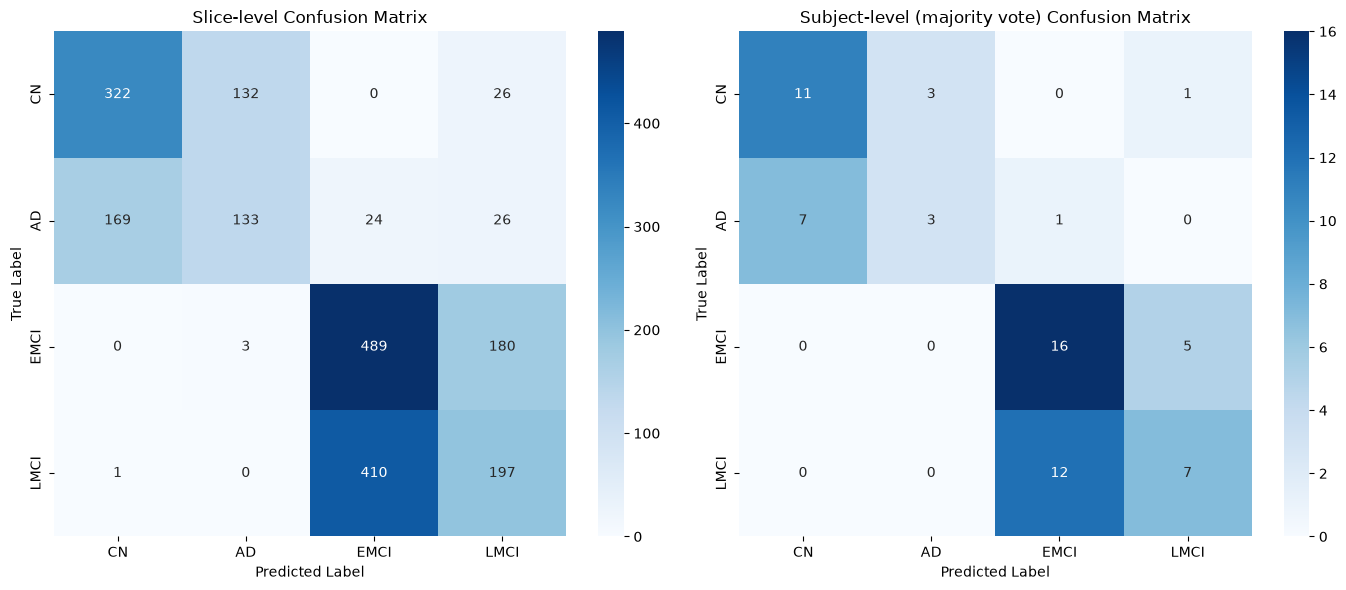

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title in [(axes[0], slice_cm, 'Slice-level'), (axes[1], subject_cm, 'Subject-level (majority vote)')]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

## 12. Qualitative Check: Sample Predictions

A fast visual gut-check independent of the aggregate metrics above -- pull random held-out test images
and look at predicted vs. true label directly. Green title = correct, red = wrong.

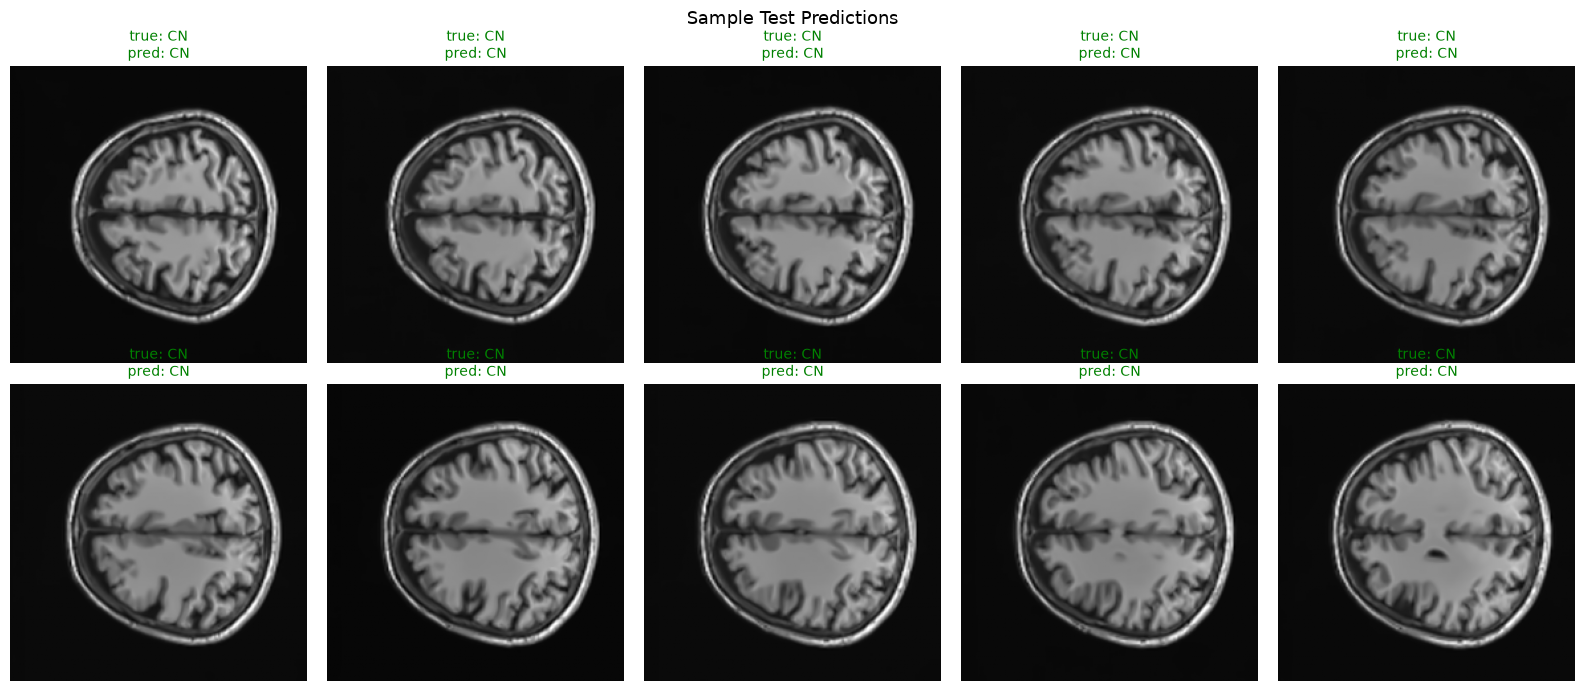

In [12]:
model.eval()
imgs, labels, subject_ids = next(iter(test_loader))
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(dim=1).cpu()

display_images = imgs * 0.5 + 0.5
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, ax in enumerate(axes.flatten()):
    true_label, pred_label = CLASSES[labels[i]], CLASSES[preds[i]]
    correct = true_label == pred_label
    ax.imshow(display_images[i, 0], cmap='gray')
    ax.set_title(f'true: {true_label}\npred: {pred_label}', fontsize=10,
                 color='green' if correct else 'red')
    ax.axis('off')
plt.suptitle('Sample Test Predictions', fontsize=13)
plt.tight_layout()
plt.show()

## 13. Save Results

The best-weights checkpoint was already saved during training (`train_model` does this every time val_loss
improves). Here we just record this model's metrics into `reports/metrics.json` so Phase D can build the
3-model comparison table against it.

In [13]:
import json
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score

metrics_path = Path('../reports/metrics.json')
all_metrics = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}

all_metrics['custom_cnn'] = {
    'n_params': n_params,
    'slice_level_accuracy': accuracy_score(test_preds['true'], test_preds['pred']),
    'slice_level_macro_f1': f1_score(test_preds['true'], test_preds['pred'], average='macro'),
    'subject_level_accuracy': accuracy_score(subject_preds['true'], subject_preds['pred']),
    'subject_level_macro_f1': f1_score(subject_preds['true'], subject_preds['pred'], average='macro'),
}
metrics_path.write_text(json.dumps(all_metrics, indent=2))
print('Saved to', metrics_path.resolve())
print(json.dumps(all_metrics['custom_cnn'], indent=2))

Saved to C:\Users\Nikunj\Documents\alzheimer-mri-project\reports\metrics.json
{
  "n_params": 1207012,
  "slice_level_accuracy": 0.5402462121212122,
  "slice_level_macro_f1": 0.5211729958462759,
  "subject_level_accuracy": 0.5606060606060606,
  "subject_level_macro_f1": 0.5242769607843137
}
